<a href="https://colab.research.google.com/github/PhanithChandu/MLA0408-DL/blob/main/DL%20lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

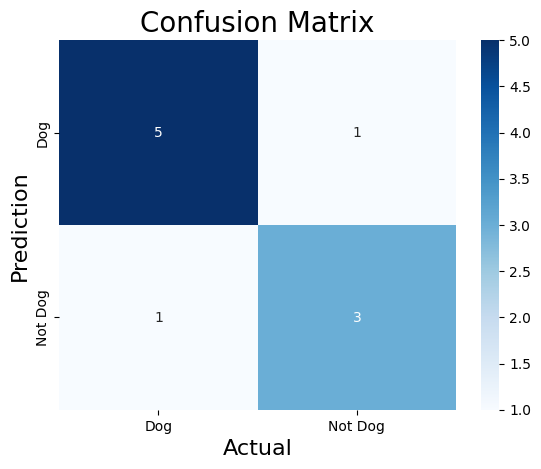

In [ ]:
# Exp 1 - To demonstrate confusion matrix using python

import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
actual = np.array(
    ['Dog','Dog','Dog','Not Dog','Dog','Not Dog','Dog','Dog','Not Dog','Not Dog'])
predicted = np.array(
    ['Dog','Not Dog','Dog','Not Dog','Dog','Dog','Dog','Dog','Not Dog','Not Dog'])
conf_matrix = confusion_matrix(actual,predicted)
sns.heatmap(conf_matrix, annot = True, xticklabels = ['Dog','Not Dog'], yticklabels=['Dog', 'Not Dog'], cmap = 'Blues')
plt.ylabel("Prediction", fontsize= 16)
plt.xlabel("Actual", fontsize=16)
plt.title("Confusion Matrix", fontsize = 20)
plt.show()

Accuracy:  0.9743589743589743
Classification Report:
               precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        17
     class_1       0.96      1.00      0.98        22

    accuracy                           0.97        39
   macro avg       0.98      0.97      0.97        39
weighted avg       0.98      0.97      0.97        39

Precision: 0.96
Recall: 1.00
F1 Score:0.98


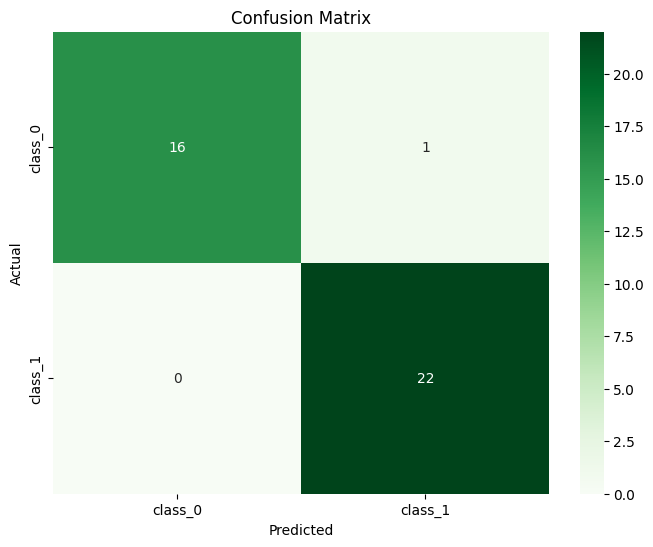

In [ ]:
# Exp 2 - To demonstrate 2 class confusion matrix using python

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, recall_score,classification_report, confusion_matrix, precision_score
wine= load_wine()
data = pd.DataFrame(data = wine.data, columns = wine.feature_names)
data['target'] = wine.target
data = data[data['target']!=2]
x = data.drop('target', axis = 1)
y = data['target']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.3, random_state = 1)
model = DecisionTreeClassifier(random_state= 1)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

class_report = classification_report(y_test, y_pred, target_names = wine.target_names[:2])
print("Classification Report:\n", class_report)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score:{f1:.2f}")
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (8,6))
sns.heatmap(conf_matrix, annot = True, xticklabels = wine.target_names[:2], yticklabels = wine.target_names[:2], cmap = 'Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

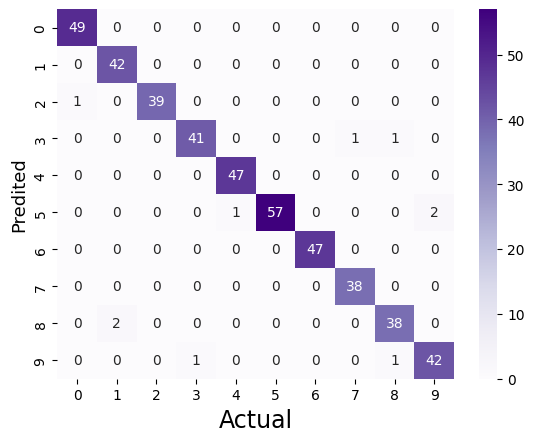

Acuracy 0.9777777777777777


In [ ]:
# Exp - 3: To analyse the the performance of a multiclass confusion matrix by using choosen database with python code

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
X,y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size = 0.25)
model = RandomForestClassifier(random_state=23)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot = True, fmt = 'd', cmap = "Purples")
plt.ylabel("Predited", fontsize = 13)
plt.xlabel("Actual", fontsize = 17)
plt.show()
accuracy = accuracy_score(y_test, y_pred)
print("Acuracy", accuracy)

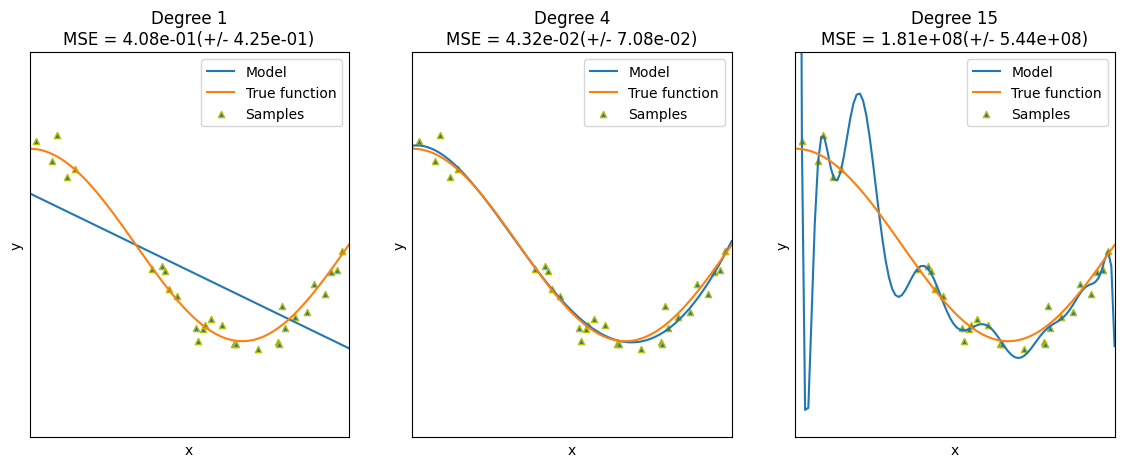

In [2]:
# Exp - 4: To analyse the performance of a over fitting by using choosen database with python code

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

def true_fun(X):
  return np.cos(1.5*np.pi*X)

np.random.seed(0)
n_samples = 30
degrees = [1,4,15]

X = np.sort(np.random.rand(n_samples))
y = true_fun(X) + np.random.randn(n_samples) * 0.1
plt.figure(figsize=(14, 5))
for i in range(len(degrees)):
  ax = plt.subplot(1, len(degrees), i + 1)
  plt.setp(ax, xticks=(), yticks=())
  polynomial_features = PolynomialFeatures(degree=degrees[i],include_bias=False)
  linear_regression = LinearRegression()
  pipeline = Pipeline(
      [
          ("polynomial_features", polynomial_features),
           ("linear_regression", linear_regression),
          ]
      )
  pipeline.fit(X[:, np.newaxis], y)
  scores = cross_val_score(pipeline, X[:, np.newaxis], y, scoring="neg_mean_squared_error", cv=10)
  X_test = np.linspace(0, 1, 100)
  plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
  plt.plot(X_test, true_fun(X_test), label="True function")
  plt.scatter(X, y, edgecolor="y", s=20,marker="^", label="Samples")
  plt.xlabel("x")
  plt.ylabel("y")
  plt.xlim((0, 1))
  plt.ylim((-2, 2))
  plt.legend(loc="best")
  plt.title(
  "Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std())
  )
plt.show()


